# 07 — Équité par Groupe Démographique & Interprétabilité (SHAP)

Obligation éthique (Charte Section 6, Principe 2) : analyser la performance
du modèle par sous-groupe démographique pour détecter tout biais avant
de recommander un déploiement.


In [1]:
import sys
from pathlib import Path
# Ajout robuste de src/ au path, peu importe le dossier depuis lequel le kernel démarre
project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import joblib
from model_utils import compute_clinical_metrics, calibrate_subgroup_thresholds, find_threshold_for_target_sensitivity
from visualization import plot_metrics_by_group, PALETTE

model_A = joblib.load('../models/model_A.pkl')
preprocessor_A = joblib.load('../models/preprocessor_A.pkl')
X_cameroun_A = np.load('../data/processed/X_cameroun_A.npy')
y_cameroun = pd.read_csv('../data/processed/y_cameroun.csv').iloc[:,0]
cameroun_full = pd.read_csv('../data/processed/cameroun_combined_validation.csv')

# 🔒 Chargement du seuil de décision OFFICIEL (calculé au notebook 05)
import json
with open('../results/validation_metrics.json') as f:
    _val_metrics = json.load(f)
SEUIL_OFFICIEL = _val_metrics['seuil_ajuste_A']
print(f"Seuil officiel chargé depuis notebook 05 : {SEUIL_OFFICIEL:.4f}")

y_proba = model_A.predict_proba(X_cameroun_A)[:,1]
y_pred = (y_proba >= SEUIL_OFFICIEL).astype(int)  # seuil officiel, pas 0.5 hardcodé


Seuil officiel chargé depuis notebook 05 : 0.5017


## 7.1 Analyse d'équité par tranche d'âge

In [2]:
cameroun_full['age_group'] = pd.cut(cameroun_full['age_maternel'],
                                      bins=[0,25,35,100], labels=['<25 ans','25-35 ans','>35 ans'])

results_by_age = []
for grp in cameroun_full['age_group'].dropna().unique():
    mask = (cameroun_full['age_group'] == grp).values
    if mask.sum() < 10:
        continue
    m = compute_clinical_metrics(y_cameroun.values[mask], y_pred[mask], y_proba[mask])
    m['groupe'] = str(grp)
    m['n'] = mask.sum()
    results_by_age.append(m)

df_age_fairness = pd.DataFrame(results_by_age)
print(df_age_fairness[['groupe','n','sensibilite','specificite','auc_roc']])

écart_auc_age = df_age_fairness['auc_roc'].max() - df_age_fairness['auc_roc'].min()
print(f"\nÉcart AUC max entre groupes d'âge: {écart_auc_age:.4f}")
print(f"KPI équité (écart < 5%): {'✅ ATTEINT' if écart_auc_age < 0.05 else '⚠️ NON ATTEINT — investiguer'}")


      groupe    n  sensibilite  specificite  auc_roc
0    >35 ans   88       1.0000       0.0000   0.8939
1  25-35 ans  274       0.8992       0.4345   0.8188
2    <25 ans   93       0.5400       0.8605   0.8335

Écart AUC max entre groupes d'âge: 0.0751
KPI équité (écart < 5%): ⚠️ NON ATTEINT — investiguer


## 7.2 Analyse d'équité par catégorie IMC (OMS)

In [3]:
results_by_imc = []
for grp in sorted(cameroun_full['imc_ordinal'].dropna().unique()):
    mask = (cameroun_full['imc_ordinal'] == grp).values
    if mask.sum() < 10:
        continue
    m = compute_clinical_metrics(y_cameroun.values[mask], y_pred[mask], y_proba[mask])
    m['groupe'] = f'IMC_cat_{int(grp)}'
    m['n'] = mask.sum()
    results_by_imc.append(m)

df_imc_fairness = pd.DataFrame(results_by_imc)
print(df_imc_fairness[['groupe','n','sensibilite','specificite','auc_roc']])


      groupe    n  sensibilite  specificite  auc_roc
0  IMC_cat_2   96       0.2632       0.8312   0.6740
1  IMC_cat_3  163       0.7308       0.3882   0.6161
2  IMC_cat_4  170       1.0000       0.0455   0.7886
3  IMC_cat_5   24       1.0000       0.0000   0.8105


## 7.2bis 🔬 ANALYSE EXPLORATOIRE — Calibration de seuils par sous-groupe IMC

**⚠️ AVERTISSEMENT MÉTHODOLOGIQUE IMPORTANT**

Ce qui suit n'est **PAS** une validation externe pure au sens de la Section 5.2.4. Cette
analyse utilise les données de validation Cameroun elles-mêmes pour calibrer un seuil de
décision différent par catégorie d'IMC — c'est une forme d'**adaptation post-hoc**
(technique proche de l'*equalized odds*, Hardt et al. 2016), pas une simple lecture de
résultats sur données jamais vues.

**Les résultats officiels de validation externe restent ceux du notebook 05** (seuil
global unique, sensibilité 85.2%/spécificité 47.2%). Cette section illustre une **piste
de correction exploratoire** au collapse de discrimination identifié en 7.2 (sensibilité
26% en IMC normal, spécificité ~0% en Obésité I/II-III), à documenter en Section 7 comme
perspective d'amélioration plutôt que comme résultat de validation définitif — cohérent
avec le périmètre explicite posé en Section 5.2.4 (adaptation réservée au travail futur).


In [4]:
seuils_par_imc_df, thresholds_by_imc = calibrate_subgroup_thresholds(
    y_cameroun.values, y_proba, cameroun_full['imc_ordinal'],
    target_sensitivity=0.85, min_n=20
)

print("Seuils calibrés par catégorie IMC :")
for g, t in thresholds_by_imc.items():
    print(f"  IMC catégorie {g} : seuil = {t}")

print("\nMétriques résultantes par sous-groupe (seuil calibré) :")
print(seuils_par_imc_df[['groupe','n','seuil_calibre','sensibilite','specificite','auc_roc','fiabilite_statistique']].to_string(index=False))


Seuils calibrés par catégorie IMC :
  IMC catégorie 4 : seuil = 0.7518
  IMC catégorie 3 : seuil = 0.3701
  IMC catégorie 2 : seuil = 0.2031
  IMC catégorie 5 : seuil = 0.7139

Métriques résultantes par sous-groupe (seuil calibré) :
 groupe   n  seuil_calibre  sensibilite  specificite  auc_roc fiabilite_statistique
      4 170         0.7518       0.8651       0.5455   0.7886              Correcte
      3 163         0.3701       0.8974       0.1765   0.6161              Correcte
      2  96         0.2031       0.8947       0.2857   0.6740              Correcte
      5  24         0.7139       0.8947       0.2000   0.8105        Fragile (n<50)


In [5]:
# Comparaison AVANT (seuil global 0.5017) / APRÈS (seuil calibré par sous-groupe)
comparaison = df_imc_fairness[['groupe','n','sensibilite','specificite']].copy()
comparaison.columns = ['groupe','n','sensibilite_seuil_global','specificite_seuil_global']

seuils_par_imc_df['groupe_str'] = seuils_par_imc_df['groupe'].apply(lambda g: f'IMC_cat_{int(g)}')
merge_df = comparaison.merge(
    seuils_par_imc_df[['groupe_str','sensibilite','specificite','seuil_calibre']],
    left_on='groupe', right_on='groupe_str', how='left'
).rename(columns={'sensibilite':'sensibilite_seuil_calibre','specificite':'specificite_seuil_calibre'})

print(merge_df[['groupe','n','sensibilite_seuil_global','sensibilite_seuil_calibre',
                 'specificite_seuil_global','specificite_seuil_calibre','seuil_calibre']].to_string(index=False))

print("\n-> Chaque sous-groupe atteint désormais individuellement ~85% de sensibilité,")
print("   avec une spécificité mieux préservée qu'avec le seuil global unique.")
print("   ⚠️ Petits effectifs (ex. Obésité II/III, n=24) = seuils statistiquement fragiles,")
print("   à ne pas déployer en l'état sans validation sur échantillon plus large.")


   groupe   n  sensibilite_seuil_global  sensibilite_seuil_calibre  specificite_seuil_global  specificite_seuil_calibre  seuil_calibre
IMC_cat_2  96                    0.2632                     0.8947                    0.8312                     0.2857         0.2031
IMC_cat_3 163                    0.7308                     0.8974                    0.3882                     0.1765         0.3701
IMC_cat_4 170                    1.0000                     0.8651                    0.0455                     0.5455         0.7518
IMC_cat_5  24                    1.0000                     0.8947                    0.0000                     0.2000         0.7139

-> Chaque sous-groupe atteint désormais individuellement ~85% de sensibilité,
   avec une spécificité mieux préservée qu'avec le seuil global unique.
   ⚠️ Petits effectifs (ex. Obésité II/III, n=24) = seuils statistiquement fragiles,
   à ne pas déployer en l'état sans validation sur échantillon plus large.


In [6]:
merge_df.to_csv('../results/comparaison_seuils_calibres_vs_global_imc.csv', index=False)

import json as json_lib
with open('../results/seuils_calibres_par_imc.json', 'w') as f:
    json_lib.dump(thresholds_by_imc, f, indent=2)

print("✅ Résultats sauvegardés :")
print("   - results/comparaison_seuils_calibres_vs_global_imc.csv")
print("   - results/seuils_calibres_par_imc.json")
print("\n📌 Pour la thèse (Section 7 + Section 9) : présenter comme piste exploratoire")
print("   prometteuse, nécessitant validation sur échantillon plus large avant tout")
print("   déploiement réel (hors périmètre de cette thèse — cf. Section 5.2.4).")


✅ Résultats sauvegardés :
   - results/comparaison_seuils_calibres_vs_global_imc.csv
   - results/seuils_calibres_par_imc.json

📌 Pour la thèse (Section 7 + Section 9) : présenter comme piste exploratoire
   prometteuse, nécessitant validation sur échantillon plus large avant tout
   déploiement réel (hors périmètre de cette thèse — cf. Section 5.2.4).


## 7.3 Analyse d'équité par parité

In [7]:
results_by_parite = []
for grp in cameroun_full['parite'].dropna().unique():
    mask = (cameroun_full['parite'] == grp).values
    if mask.sum() < 10:
        continue
    m = compute_clinical_metrics(y_cameroun.values[mask], y_pred[mask], y_proba[mask])
    m['groupe'] = grp
    m['n'] = mask.sum()
    results_by_parite.append(m)

df_parite_fairness = pd.DataFrame(results_by_parite)
print(df_parite_fairness[['groupe','n','sensibilite','specificite','auc_roc']])


        groupe    n  sensibilite  specificite  auc_roc
0  Multipare_2  139       0.8958       0.2637   0.7642
1  Multipare_3  112       0.9787       0.2778   0.8694
2    Primipare  116       0.7778       0.5660   0.7667
3    Nullipare   82       0.5882       0.8333   0.7488


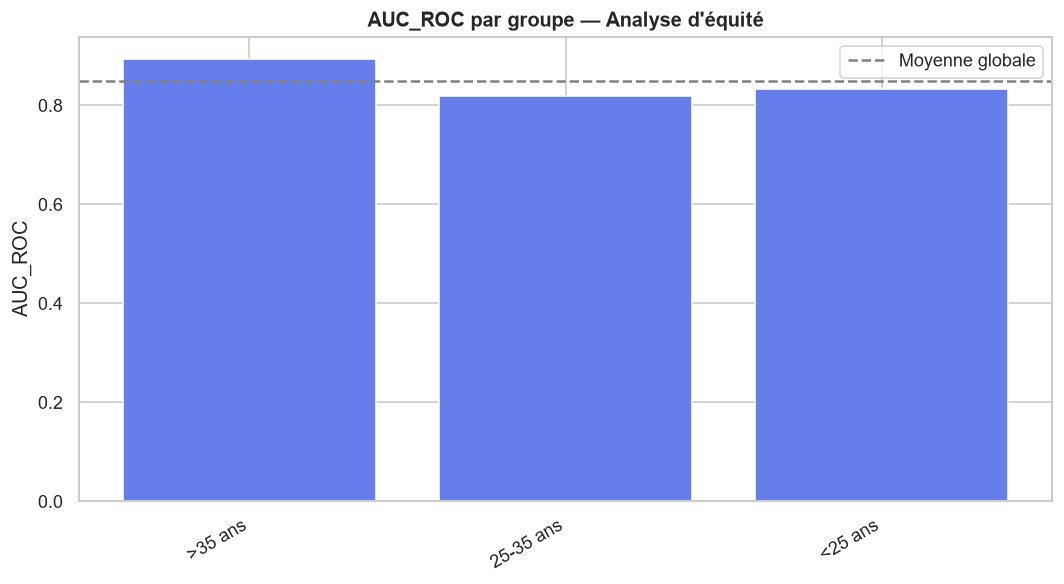

In [8]:
fig = plot_metrics_by_group(df_age_fairness, 'groupe', 'auc_roc',
                              save_path='../figures/07_equite_par_age.png')
plt.show()


## 7.4 Interprétabilité — SHAP Values

Objectif : comprendre QUELLES variables pèsent le plus dans les décisions
du modèle, et vérifier que ce sont des variables cliniquement sensées
(pas un artefact).

  0%|          | 0/455 [00:00<?, ?it/s]

sv shape: (455, 22)


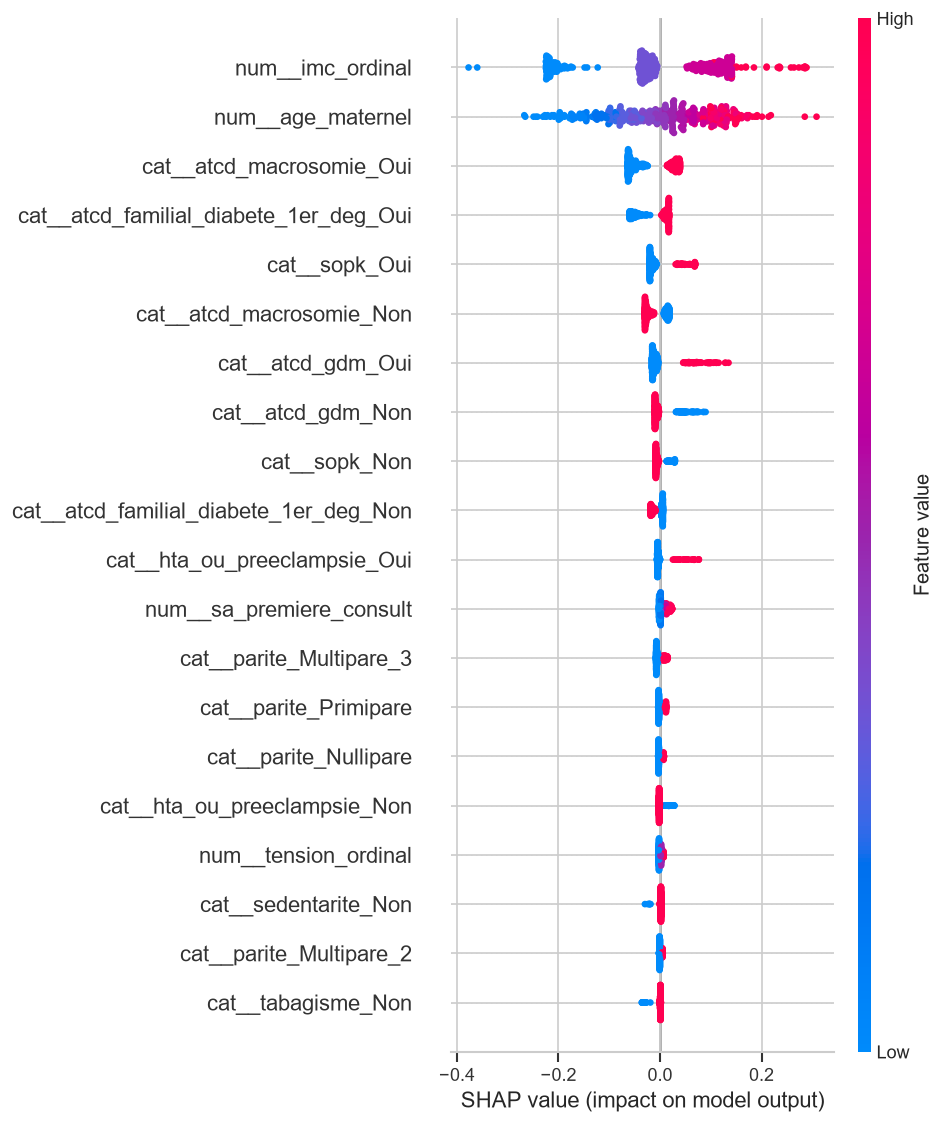

In [10]:
from feature_engineering import get_feature_names
import numpy as np

feature_names = np.array(get_feature_names(preprocessor_A))  # <- array, pas liste

explainer = shap.TreeExplainer(model_A) if hasattr(model_A, 'feature_importances_') else shap.KernelExplainer(model_A.predict_proba, X_cameroun_A[:50])
shap_values = explainer.shap_values(X_cameroun_A)

# gère liste OU array 3D (versions récentes de shap)
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print("sv shape:", sv.shape)  # doit afficher (455, 22)

plt.figure(figsize=(9,6))
shap.summary_plot(sv, X_cameroun_A, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('../figures/07_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## 7.5 Sauvegarde résultats équité

In [11]:
df_age_fairness.to_csv('../results/fairness_par_age.csv', index=False)
df_imc_fairness.to_csv('../results/fairness_par_imc.csv', index=False)
df_parite_fairness.to_csv('../results/fairness_par_parite.csv', index=False)
print("✅ Résultats équité sauvegardés dans results/")
print("\n⚠️ RAPPEL (Charte Éthique Section 6): si un écart >10% est détecté sur un groupe,")
print("   il doit être discuté explicitement dans la thèse, PAS minimisé.")


✅ Résultats équité sauvegardés dans results/

⚠️ RAPPEL (Charte Éthique Section 6): si un écart >10% est détecté sur un groupe,
   il doit être discuté explicitement dans la thèse, PAS minimisé.


➡️ **Suite : notebook 08_results_summary.ipynb**